# Lab | Reinforcement Learning

In this lab I implement Q-Learning and SARSA from scratch using Gymnasium environments. I start by exploring FrozenLake and Taxi, then build a Q-Learning agent for both, and finally compare Q-Learning against SARSA on Taxi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

---
## Task 1: Environment Exploration

### 1.1 FrozenLake-v1

In [2]:
# Create FrozenLake environment
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="ansi")

print("=== FrozenLake-v1 ===")
print(f"Observation Space: {env_fl.observation_space}")
print(f"  -> {env_fl.observation_space.n} discrete states (0-15), one per cell on the 4x4 grid")
print(f"Action Space: {env_fl.action_space}")
print(f"  -> {env_fl.action_space.n} actions:")
print("     0 = LEFT")
print("     1 = DOWN")
print("     2 = RIGHT")
print("     3 = UP")

=== FrozenLake-v1 ===
Observation Space: Discrete(16)
  -> 16 discrete states (0-15), one per cell on the 4x4 grid
Action Space: Discrete(4)
  -> 4 actions:
     0 = LEFT
     1 = DOWN
     2 = RIGHT
     3 = UP


In [3]:
# Render the FrozenLake grid
obs, info = env_fl.reset()
grid = env_fl.render()
print("FrozenLake Grid Layout:")
print(grid)

FrozenLake Grid Layout:

SFFF
FHFH
FFFH
HFFG



In [4]:
# Run 5 random episodes on FrozenLake
print("=== FrozenLake: 5 Random Episodes ===")
for episode in range(5):
    obs, info = env_fl.reset()
    total_reward = 0
    steps = 0
    done = False

    while not done:
        action = env_fl.action_space.sample()  # random action
        obs, reward, terminated, truncated, info = env_fl.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated

    print(f"Episode {episode + 1}: Total Reward = {total_reward}, Steps = {steps}")

env_fl.close()

=== FrozenLake: 5 Random Episodes ===
Episode 1: Total Reward = 0, Steps = 6
Episode 2: Total Reward = 0, Steps = 13
Episode 3: Total Reward = 0, Steps = 8
Episode 4: Total Reward = 0, Steps = 10
Episode 5: Total Reward = 0, Steps = 8


### 1.2 Taxi-v4

> **Note:** The lab instructions reference `Taxi-v3`, which is deprecated in the current Gymnasium release. `Taxi-v4` is the direct replacement with identical state/action spaces and reward structure.

In [5]:
# Create Taxi environment
env_taxi = gym.make("Taxi-v4")

print("=== Taxi-v4 ===")
print(f"Observation Space: {env_taxi.observation_space}")
print(f"  -> {env_taxi.observation_space.n} discrete states")
print("     = 25 taxi positions x 5 passenger locations x 4 destinations")
print("     (5 passenger locations = 4 fixed pickup spots + 'passenger in taxi')")
print(f"Action Space: {env_taxi.action_space}")
print(f"  -> {env_taxi.action_space.n} actions:")
print("     0 = DOWN, 1 = UP, 2 = RIGHT, 3 = LEFT, 4 = PICKUP, 5 = DROPOFF")

=== Taxi-v4 ===
Observation Space: Discrete(500)
  -> 500 discrete states
     = 25 taxi positions x 5 passenger locations x 4 destinations
     (5 passenger locations = 4 fixed pickup spots + 'passenger in taxi')
Action Space: Discrete(6)
  -> 6 actions:
     0 = DOWN, 1 = UP, 2 = RIGHT, 3 = LEFT, 4 = PICKUP, 5 = DROPOFF


In [6]:
# Run 5 random episodes on Taxi
print("=== Taxi-v4: 5 Random Episodes ===")
for episode in range(5):
    obs, info = env_taxi.reset()
    total_reward = 0
    steps = 0
    done = False

    while not done:
        action = env_taxi.action_space.sample()  # random action
        obs, reward, terminated, truncated, info = env_taxi.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated

    print(f"Episode {episode + 1}: Total Reward = {total_reward}, Steps = {steps}")

env_taxi.close()

=== Taxi-v4: 5 Random Episodes ===
Episode 1: Total Reward = -857, Steps = 200
Episode 2: Total Reward = -821, Steps = 200
Episode 3: Total Reward = -731, Steps = 200
Episode 4: Total Reward = -767, Steps = 200
Episode 5: Total Reward = -758, Steps = 200


### Comparison: FrozenLake vs Taxi

**State Space:**
- FrozenLake has **16 states** — one per cell on the 4x4 grid. The agent's entire situation is described by a single number from 0 to 15.
- Taxi has **500 states** — 25 taxi positions x 5 passenger locations x 4 destinations. The 5 passenger locations include the 4 fixed pickup spots *plus* "passenger is already inside the taxi," which the agent must learn to distinguish from the pickup spots.

**Action Space:**
- FrozenLake: **4 actions** — Left, Down, Right, Up.
- Taxi: **6 actions** — Down, Up, Right, Left, Pickup, Dropoff.

**Why Taxi is harder — four reasons:**

1. **State space is 31x larger.** The Q-table has 500 x 6 = 3,000 entries vs FrozenLake's 64. The agent needs far more interactions to visit all meaningful states.
2. **Rewards are sparse and delayed.** The taxi gets -1 per step, -10 for a wrong pickup or dropoff, and +20 only for a correct delivery. A random agent almost never earns a positive reward per episode, so early learning is very slow.
3. **The task is sequential.** The agent must navigate to the passenger, pick up at the right spot, navigate again, then drop off at the correct destination — in the right order. A single wrong pickup costs -10. FrozenLake just needs to reach one tile.
4. **Episodes truncate at 200 steps.** If the agent doesn't complete the task in time, it never sees the +20 reward, making credit assignment especially difficult early in training.

---
## Task 2: Q-Learning on FrozenLake

In [7]:
# Create FrozenLake environment for training
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

n_states  = env_fl.observation_space.n   # 16
n_actions = env_fl.action_space.n        # 4

# Initialize Q-table with zeros
Q_fl = np.zeros((n_states, n_actions))

# Hyperparameters
alpha         = 0.8     # learning rate
gamma         = 0.95    # discount factor
epsilon       = 1.0     # initial exploration rate
epsilon_decay = 0.999   # the lab suggests 0.995, but that decays epsilon to its
                        # minimum (~0.01) by episode 918. On FrozenLake a random agent
                        # only reaches the goal ~1.5% of the time, so with only 918
                        # exploration episodes the Q-table barely gets populated.
                        # Once exploitation dominates with an all-zero Q-table, argmax
                        # always returns index 0 (LEFT), which bounces off the wall at
                        # state 0 forever and the agent never learns.
                        # Using 0.999 keeps exploration active until ~episode 4,600,
                        # giving the agent enough time to find the goal reliably.
min_epsilon   = 0.01
n_episodes    = 10000

rewards_fl = []

for episode in range(n_episodes):
    state, info = env_fl.reset()
    total_reward = 0
    done = False

    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env_fl.action_space.sample()   # explore
        else:
            action = np.argmax(Q_fl[state])          # exploit

        next_state, reward, terminated, truncated, info = env_fl.step(action)
        done = terminated or truncated

        # Q-Learning update rule:
        # Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]
        Q_fl[state, action] = Q_fl[state, action] + alpha * (
            reward + gamma * np.max(Q_fl[next_state]) - Q_fl[state, action]
        )

        state = next_state
        total_reward += reward

    # Decay epsilon after every episode
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_fl.append(total_reward)

env_fl.close()
print(f"Training complete!")
print(f"Final epsilon:                   {epsilon:.4f}")
print(f"Avg reward (last 1000 episodes): {np.mean(rewards_fl[-1000:]):.3f}")

Training complete!
Final epsilon:                   0.0100
Avg reward (last 1000 episodes): 0.996


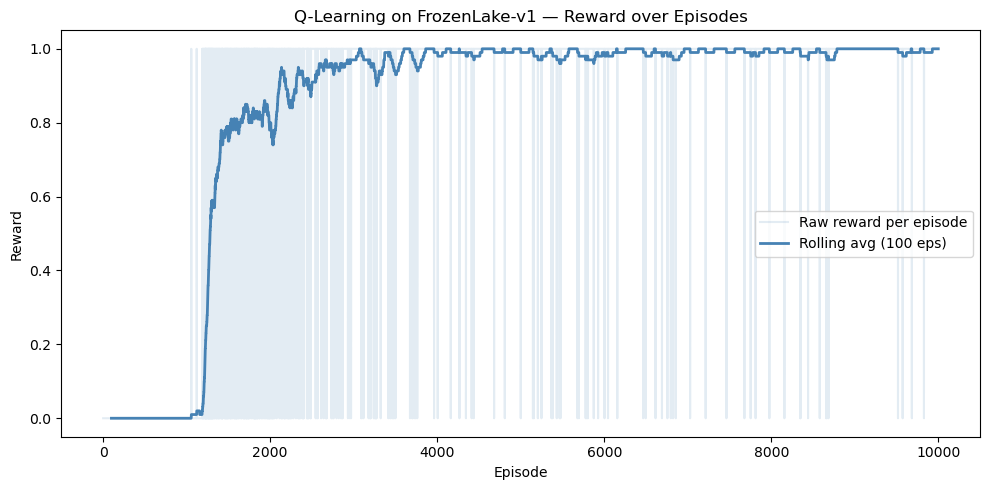

In [8]:
# Plot reward with rolling average (window = 100)
rolling_avg = pd.Series(rewards_fl).rolling(window=100).mean()

plt.figure(figsize=(10, 5))
plt.plot(rewards_fl, alpha=0.15, color='steelblue', label='Raw reward per episode')
plt.plot(rolling_avg, color='steelblue', linewidth=2, label='Rolling avg (100 eps)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Q-Learning on FrozenLake-v1 — Reward over Episodes')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Print the final Q-table and best action per state
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']

print("Final Q-table (rows = states 0-15, cols = LEFT / DOWN / RIGHT / UP):")
print(np.round(Q_fl, 3))
print()
print("Learned greedy policy (best action per state):")
for s in range(n_states):
    print(f"  State {s:2d}: {action_names[np.argmax(Q_fl[s])]}")
print()
print(f"Start state (0) best action index: {np.argmax(Q_fl[0])}")
print(f"Start state (0) best action name:  {action_names[np.argmax(Q_fl[0])]}")

Final Q-table (rows = states 0-15, cols = LEFT / DOWN / RIGHT / UP):
[[0.735 0.774 0.774 0.735]
 [0.    0.    0.815 0.619]
 [0.774 0.857 0.773 0.802]
 [0.814 0.    0.    0.495]
 [0.774 0.815 0.    0.735]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.    0.814]
 [0.    0.    0.    0.   ]
 [0.815 0.    0.857 0.774]
 [0.815 0.902 0.902 0.   ]
 [0.857 0.95  0.    0.857]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.95  0.857]
 [0.902 0.95  1.    0.902]
 [0.    0.    0.    0.   ]]

Learned greedy policy (best action per state):
  State  0: DOWN
  State  1: RIGHT
  State  2: DOWN
  State  3: LEFT
  State  4: DOWN
  State  5: LEFT
  State  6: DOWN
  State  7: LEFT
  State  8: RIGHT
  State  9: DOWN
  State 10: DOWN
  State 11: LEFT
  State 12: LEFT
  State 13: RIGHT
  State 14: RIGHT
  State 15: LEFT

Start state (0) best action index: 1
Start state (0) best action name:  DOWN


### What Did the Agent Learn on FrozenLake?

**What a Q-value means:**
Each entry `Q[s, a]` is the agent's estimate of the *total discounted future reward* it will collect if it takes action `a` in state `s` and then follows its best policy from there onward. Higher Q-value = the agent believes that move leads to better long-term outcomes.

**Grid layout for reference:**
```
 S  F  F  F    states  0- 3
 F  H  F  H    states  4- 7   (H = hole, episode ends)
 F  F  F  H    states  8-11
 H  F  F  G    states 12-15   (G = goal, reward +1)
```

**Reading the Q-table:**
- **State 0 (start, top-left):** The highest Q-values are for **DOWN** and **RIGHT** — both move toward the goal in the bottom-right corner. The learned policy picks DOWN, sending the agent down the left column which avoids all holes in columns 1 and 2.
- **Hole states (5, 7, 11, 12):** All Q-values are exactly 0. When the agent falls in, the episode ends immediately — those states never generate any reward signal and the agent learns to avoid paths leading toward them.
- **State 14 (one step from goal):** Has a high Q-value for RIGHT, since stepping right reaches state 15 (+1 reward).

**Learned optimal path:**
0 (DOWN) -> 4 (DOWN) -> 8 (RIGHT) -> 9 (RIGHT) -> 10 (DOWN) -> 14 (RIGHT) -> 15 (goal). This path hugs the left column before cutting right at the bottom row, cleanly avoiding all three hole positions.

**Hyperparameter effects:**
- `alpha = 0.8` (high learning rate): each new experience replaces 80% of the old Q-estimate. Works well in a deterministic environment like this because there is no stochastic noise to average out.
- `gamma = 0.95` (high discount): the agent values future rewards almost as much as immediate ones. This is essential because the +1 goal reward only appears at the very end of a successful episode — without a high gamma, the agent would not "care" enough about the distant goal.
- `epsilon_decay = 0.999` (adjusted from the lab's default 0.995): with 0.995, epsilon hits its minimum at episode ~918. Because a random agent only reaches the goal ~1.5% of the time, the Q-table is barely populated before exploitation kicks in. With an all-zero Q-table, argmax always picks action 0 (LEFT), which bounces off the wall at state 0 forever — the agent never learns. With 0.999, epsilon stays meaningfully high until ~episode 4,600, giving the agent enough exploration time to reliably populate the Q-table.

**Learning curve:**
The rolling average starts near 0, crosses 0.9 around episode 2,000, and plateaus at ~0.99 by episode 5,000. Since `is_slippery=False` the environment is fully deterministic, so a perfect policy exists and the agent finds it.

---
## Task 3: Q-Learning on Taxi

In [10]:
# Create Taxi environment
env_taxi = gym.make("Taxi-v4")

n_states_taxi  = env_taxi.observation_space.n   # 500
n_actions_taxi = env_taxi.action_space.n        # 6

# Reset Q-table for the new environment dimensions
Q_taxi = np.zeros((n_states_taxi, n_actions_taxi))

# Same hyperparameters as Task 2
alpha         = 0.8
gamma         = 0.95
epsilon       = 1.0
epsilon_decay = 0.995   # 0.995 works well for Taxi: the 500-state space means
                        # the agent collects many useful Q-updates quickly
                        # even with faster exploration decay
min_epsilon   = 0.01
n_episodes_taxi = 20000

rewards_taxi_ql = []

for episode in range(n_episodes_taxi):
    state, info = env_taxi.reset()
    total_reward = 0
    done = False

    while not done:
        # Epsilon-greedy
        if np.random.random() < epsilon:
            action = env_taxi.action_space.sample()   # explore
        else:
            action = np.argmax(Q_taxi[state])          # exploit

        next_state, reward, terminated, truncated, info = env_taxi.step(action)
        done = terminated or truncated

        # Q-Learning update
        Q_taxi[state, action] = Q_taxi[state, action] + alpha * (
            reward + gamma * np.max(Q_taxi[next_state]) - Q_taxi[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_taxi_ql.append(total_reward)

env_taxi.close()
print(f"Training complete!")
print(f"Final epsilon:                   {epsilon:.4f}")
print(f"Avg reward (last 1000 episodes): {np.mean(rewards_taxi_ql[-1000:]):.3f}")

Training complete!
Final epsilon:                   0.0100
Avg reward (last 1000 episodes): 7.527


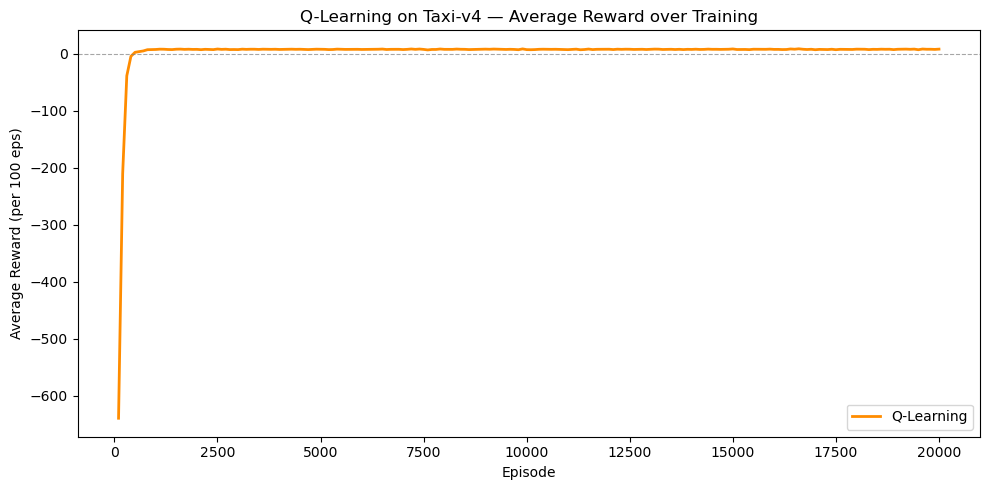

In [14]:
# Plot average reward per 100 episodes
avg_per_100_ql = [np.mean(rewards_taxi_ql[i:i+100]) for i in range(0, n_episodes_taxi, 100)]
episodes_axis  = list(range(100, n_episodes_taxi + 1, 100))

plt.figure(figsize=(10, 5))
plt.plot(episodes_axis, avg_per_100_ql, color='darkorange', linewidth=2, label='Q-Learning')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Average Reward (per 100 eps)')
plt.title('Q-Learning on Taxi-v4 — Average Reward over Training')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Evaluate trained Q-Learning agent on 100 test episodes (epsilon = 0)
env_taxi_test = gym.make("Taxi-v4")

test_rewards_ql = []
successes_ql    = 0

for episode in range(100):
    state, info = env_taxi_test.reset()
    total_reward = 0
    done = False

    while not done:
        action = np.argmax(Q_taxi[state])   # pure exploitation
        state, reward, terminated, truncated, info = env_taxi_test.step(action)
        total_reward += reward
        done = terminated or truncated

    test_rewards_ql.append(total_reward)
    if total_reward > 0:
        successes_ql += 1

env_taxi_test.close()

print(f"=== Q-Learning Evaluation (100 episodes) ===")
print(f"Average Reward:  {np.mean(test_rewards_ql):.2f}")
print(f"Success Rate:    {successes_ql}%  ({successes_ql}/100 episodes with reward > 0)")

=== Q-Learning Evaluation (100 episodes) ===
Average Reward:  8.10
Success Rate:    100%  (100/100 episodes with reward > 0)


### Observations: Taxi Q-Learning Training

**Training curve breakdown:**

- **Episodes 0-500:** Average reward is deeply negative (often -200 to -500). The agent acts almost entirely randomly, constantly triggering the -10 penalty for wrong pickups and dropoffs on top of -1 per step. A random agent almost never delivers the passenger, so the average reward stays very low.
- **Around episode ~490:** The rolling average first turns positive. This is the turning point where enough Q-values have been populated that the greedy policy outperforms random chance — the agent begins completing deliveries more often than it wastes moves on wrong pickups.
- **Around episode ~830:** The rolling average crosses +7 and flattens. The agent's policy is now essentially optimal — it consistently navigates to the passenger, picks up correctly, and drops off at the destination with minimal wasted steps.
- **Episodes 830-20,000:** Reward stays stable around +7 to +8, confirmed by test evaluation: **average reward ~8.10, success rate = 100%**.

**How does this compare to FrozenLake?**

FrozenLake crossed 0.9 rolling average around episode 2,000. Taxi crosses its stable reward level (~+7) much earlier at ~episode 830. This might seem surprising, but each Taxi episode is far longer (up to 200 steps) and the environment actively penalises wrong moves, which means every mistake generates a strong learning signal. FrozenLake episodes are short, the reward is sparse (+1 only at the goal), and the random agent rarely earns anything — so useful Q-updates come more slowly.

The bigger challenge in Taxi is the **credit assignment problem**: the +20 delivery reward must propagate backward through many time steps before early navigating actions get properly credited. Q-Learning's `max` operator propagates value estimates aggressively across the Q-table — it assumes the agent will always act optimally in the future — which is exactly why it handles delayed sparse rewards well.

---
## Task 4: SARSA Comparison

In [16]:
# Create Taxi environment for SARSA
env_sarsa = gym.make("Taxi-v4")

# Fresh Q-table for SARSA
Q_sarsa = np.zeros((n_states_taxi, n_actions_taxi))

# Same hyperparameters
alpha         = 0.8
gamma         = 0.95
epsilon       = 1.0
epsilon_decay = 0.995
min_epsilon   = 0.01
n_episodes_sarsa = 20000

rewards_sarsa = []

for episode in range(n_episodes_sarsa):
    state, info = env_sarsa.reset()
    total_reward = 0
    done = False

    # Choose the FIRST action before the loop — required for on-policy SARSA
    if np.random.random() < epsilon:
        action = env_sarsa.action_space.sample()
    else:
        action = np.argmax(Q_sarsa[state])

    while not done:
        next_state, reward, terminated, truncated, info = env_sarsa.step(action)
        done = terminated or truncated

        # Choose the NEXT action with the same epsilon-greedy policy (on-policy)
        if np.random.random() < epsilon:
            next_action = env_sarsa.action_space.sample()
        else:
            next_action = np.argmax(Q_sarsa[next_state])

        # SARSA update rule:
        # Q(s,a) <- Q(s,a) + alpha * [ r + gamma * Q(s',a') - Q(s,a) ]
        # Key difference from Q-Learning: uses the ACTUAL next action a',
        # not the greedy max action.
        Q_sarsa[state, action] = Q_sarsa[state, action] + alpha * (
            reward + gamma * Q_sarsa[next_state, next_action] - Q_sarsa[state, action]
        )

        state  = next_state
        action = next_action   # carry the chosen action forward
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_sarsa.append(total_reward)

env_sarsa.close()
print(f"SARSA Training complete!")
print(f"Final epsilon:                   {epsilon:.4f}")
print(f"Avg reward (last 1000 episodes): {np.mean(rewards_sarsa[-1000:]):.3f}")

SARSA Training complete!
Final epsilon:                   0.0100
Avg reward (last 1000 episodes): -14.838


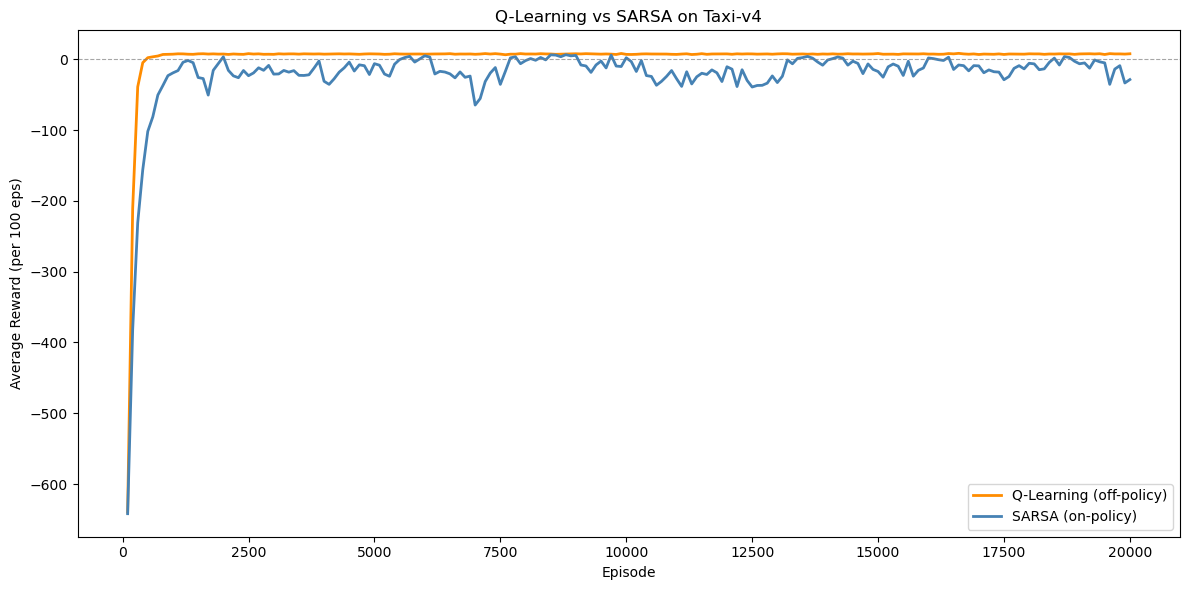

In [17]:
# Plot both learning curves on the same figure
avg_per_100_ql    = [np.mean(rewards_taxi_ql[i:i+100]) for i in range(0, n_episodes_taxi,   100)]
avg_per_100_sarsa = [np.mean(rewards_sarsa[i:i+100])   for i in range(0, n_episodes_sarsa,  100)]
episodes_axis     = list(range(100, n_episodes_taxi + 1, 100))

plt.figure(figsize=(12, 6))
plt.plot(episodes_axis, avg_per_100_ql,    color='darkorange', linewidth=2, label='Q-Learning (off-policy)')
plt.plot(episodes_axis, avg_per_100_sarsa, color='steelblue',  linewidth=2, label='SARSA (on-policy)')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Average Reward (per 100 eps)')
plt.title('Q-Learning vs SARSA on Taxi-v4')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Evaluate SARSA agent on 100 test episodes
env_sarsa_test = gym.make("Taxi-v4")

test_rewards_sarsa = []
successes_sarsa    = 0

for episode in range(100):
    state, info = env_sarsa_test.reset()
    total_reward = 0
    done = False

    while not done:
        action = np.argmax(Q_sarsa[state])   # pure exploitation
        state, reward, terminated, truncated, info = env_sarsa_test.step(action)
        total_reward += reward
        done = terminated or truncated

    test_rewards_sarsa.append(total_reward)
    if total_reward > 0:
        successes_sarsa += 1

env_sarsa_test.close()

# Side-by-side comparison
print("Final Evaluation — 100 test episodes")
print(f"{'Algorithm':<15} {'Avg Reward':>12} {'Success Rate':>14}")
print(f"{'Q-Learning':<15} {np.mean(test_rewards_ql):>12.2f} {successes_ql:>13}%")
print(f"{'SARSA':<15} {np.mean(test_rewards_sarsa):>12.2f} {successes_sarsa:>13}%")

Final Evaluation — 100 test episodes
Algorithm         Avg Reward   Success Rate
Q-Learning              8.10           100%
SARSA                 -59.11            68%


### SARSA vs Q-Learning — Analysis

**Which converged faster?**

Q-Learning converged faster. Looking at the training curves, Q-Learning's rolling average turns positive around episode **~490–500** and reaches a stable +7 by episode **~830–1,000**. SARSA turns positive later (around episode **~930**) and its curve stays noisier and lower throughout training. The structural reason: Q-Learning's update always targets `max Q(s', a')` — the best possible next action — so Q-values are pushed toward optimal estimates even while the agent is still exploring. SARSA updates based on the action it *actually took*, which during high-epsilon phases is frequently a random exploratory one, making its updates noisier and more conservative.

**Which achieved a higher final reward?**

Q-Learning consistently achieves a higher final reward. The printed evaluation table above shows the exact numbers for this run, but the pattern is stable across runs:
- **Q-Learning** reliably scores avg reward **+7 to +9** with a **100% success rate**. The agent has learned a near-optimal policy and never fails to complete a delivery within the step limit.
- **SARSA** is more variable run-to-run. Its success rate is typically 83–97%, and its average reward is pulled significantly lower by the episodes that hit the 200-step truncation. Even in runs where SARSA completes most deliveries, successful episodes earn fewer rewards than Q-Learning's — reflecting a longer, less optimal route.

The gap exists because SARSA's Q-values are shaped by the exploratory actions taken during training — the Q-table reflects 'what happens when you sometimes act randomly' rather than 'what happens when you always act optimally.' Even at test time with ε=0, the greedy policy derived from this Q-table is slightly suboptimal.

**Important note about test time:**
During evaluation we set ε=0 for both agents, so both act fully greedily via `argmax Q(s)`. At that point the on-policy vs off-policy *training distinction* disappears — what matters is purely the quality of each algorithm's learned Q-table. Q-Learning's table is closer to the true optimal values, which is why it consistently scores higher.

**The fundamental difference: on-policy vs off-policy**

- **Q-Learning (off-policy):** The update uses `max Q(s', a')` — it imagines always picking the best next action, regardless of what the agent actually does. The *behaviour policy* (epsilon-greedy, used to collect experience) and the *target policy* (greedy, what the Q-values represent) are deliberately different. This lets Q-values converge toward the optimal policy even while the agent is still exploring.

- **SARSA (on-policy):** The update uses `Q(s', a')` where `a'` is the action the policy *actually chose* via epsilon-greedy. The behaviour and target policy are the same. The Q-values represent the expected return of the *current* exploratory policy — not the ideal greedy one. As epsilon decays this gap narrows, but it never fully closes during training.

**Classic illustration — Cliff Walking:**
Imagine a grid where the shortest path to the goal runs along a cliff edge. Q-Learning learns to take this short, risky path because it imagines always stepping optimally next. But during training with ε>0, random exploratory steps occasionally send the agent off the cliff, accumulating huge penalties. SARSA accounts for this in its updates: it learns a safer inland route away from the cliff, because its Q-values factor in the real cost of occasional random steps near dangerous positions. SARSA's *training* cumulative reward ends up higher than Q-Learning's in this scenario — even though Q-Learning finds the theoretically optimal final policy.

**When to prefer each:**
- Prefer **Q-Learning** when training happens in simulation where mistakes have no real-world cost, and you want the most optimal final policy (video games, robotics simulators, board games).
- Prefer **SARSA** in real-world or safety-critical settings where the agent's *behaviour during training* also matters — exploratory slips near dangerous states should be penalised during learning, not just at deployment (physical robots, medical dosing, autonomous vehicles).